# MLP Character-Level Language Model

This notebook implements a Multi-Layer Perceptron (MLP) for character-level language modeling. The model predicts the next character in a sequence based on the previous characters, trained on a dataset of names.

## Architecture
- **Embedding layer**: Maps characters to dense vectors
- **Hidden layer**: Fully connected layer with tanh activation
- **Output layer**: Linear layer predicting character probabilities

## Dataset
- Uses `dataset/names.txt` containing 32,033 names
- Characters are encoded as integers (27 total: a-z + '.')

## Data Preprocessing

### Vocabulary
Characters are mapped to integers using:
- `stoi`: character to index mapping
- `itos`: index to character mapping
- Special '.' character represents sequence boundaries

### Data Split
- **Training**: 80% of names
- **Development/Dev**: 10% of names
- **Test**: 10% of names

### Block Size
Uses `block_size=3`, meaning the model sees 3 previous characters to predict the next one.

In [1]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def build_dataset(words: list, stoi: dict) -> tuple:
    device = 'cuda' if torch.cuda.is_available() else "cpu"
    block_size = 3
    X, Y = [], []

    for w in words:
        content = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(content)
            Y.append(ix)
            content = content[1:] + [ix]

    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    return X, Y

In [3]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
f"Tensors are saved on {device}"

'Tensors are saved on cuda'

In [4]:
words = open("dataset/names.txt", 'r').read().splitlines()
f"Number of names {len(words)}"

'Number of names 32033'

In [5]:
chars = sorted(set(list(''.join(words))))
stoi = {ch: i+1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}

In [6]:
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X, Y = build_dataset(words, stoi)
Xtr, Ytr = build_dataset(words[:n1], stoi)
Xde, Yde = build_dataset(words[n1:n2], stoi)
Xte, Yte = build_dataset(words[n2:], stoi)

In [7]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

## Model Architecture

### Embedding Layer
- `C`: Learnable embedding matrix of shape (27, embedding_dim)
- Converts character indices to dense vectors
- Example: With embedding_dim=2, each character gets a 2D vector

### Hidden Layer
- `W1`: Weight matrix (6, 100) - input size is block_size * embedding_dim
- `B1`: Bias vector (100,)
- Activation: tanh

### Output Layer
- `W2`: Weight matrix (100, 27) - maps hidden to vocabulary
- `B2`: Bias vector (27,)
- Produces logits for each character in vocabulary

In [8]:
C = torch.randn((27, 2)).to(device)
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [9]:
emb[1]

tensor([[ 0.9563,  0.1793],
        [ 0.9563,  0.1793],
        [-0.2615, -0.3207]], device='cuda:0')

In [10]:
W1 = torch.randn((6,100)).to(device)
B1 = torch.randn(100).to(device)
h = torch.tanh(emb.view(-1, 6) @ W1 + B1)

In [11]:
h.shape

torch.Size([228146, 100])

In [12]:
W2 = torch.randn((100,27)).to(device)
B2 = torch.randn(27).to(device)
logits = h @ W2 + B2

## Loss Function

### Manual Cross-Entropy
1. **Softmax**: Convert logits to probabilities
   ```python
   prob = logits.exp() / logits.exp().sum(1, keepdim=True)
   ```

2. **Negative Log-Likelihood Loss**:
   ```python
   loss = -prob[torch.arange(len(Y)), Y].log().mean()
   ```
   - Selects the probability of the target character
   - Takes negative log and averages

### Cross-Entropy Loss (PyTorch)
Using `F.cross_entropy(logits, Y)` combines softmax + log + mean in one optimized function.

In [13]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)

In [14]:
prob.shape

torch.Size([228146, 27])

In [15]:
loss = -prob[torch.arange(len(Y)), Y].log().mean()
loss

tensor(19.3322, device='cuda:0')

In [16]:
Xtr.size(), Ytr.size()

(torch.Size([182625, 3]), torch.Size([182625]))

In [17]:
g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((27,10), generator=g, device=device)        ; C.requires_grad = True
W1 = torch.randn((30,200), generator=g, device=device)      ; W1.requires_grad = True
B1 = torch.randn(200, generator=g, device=device)           ; B1. requires_grad = True
W2 = torch.randn((200,27), generator=g, device=device)      ; W2.requires_grad = True
B2 = torch.randn(27, generator=g, device=device)            ; B2.requires_grad = True
parameters = [C, W1, B1, W2, B2]

## Training

### Hyperparameters
- **Batch size**: 32
- **Embedding dimension**: 10
- **Hidden layer size**: 200
- **Learning rate**: 0.1 (epochs 0-100k), 0.01 (epochs 100k-200k)
- **Total epochs**: 200,000

### Training Process
1. **Forward pass**: Embeddings → Hidden layer (tanh) → Output logits
2. **Loss computation**: Cross-entropy between predictions and targets
3. **Backward pass**: Compute gradients via autograd
4. **Optimization**: Update parameters using gradient descent

### Learning Rate Schedule
- Learning rate decreases after 100k epochs to fine-tune the model

### Training Metrics
- Tracks loss over time (stepi, lossi) for visualization

In [18]:
stepi = []
lossi = []

for epoch in range(200000):
    batch = torch.randint(0, Xtr.shape[0], (32,))
    emb = C[Xtr[batch]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits, Ytr[batch])
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if epoch < 100000 else 0.01
    for p in parameters:
        p.data -= lr*p.grad

    stepi.append(epoch)
    lossi.append(loss.log10().item())

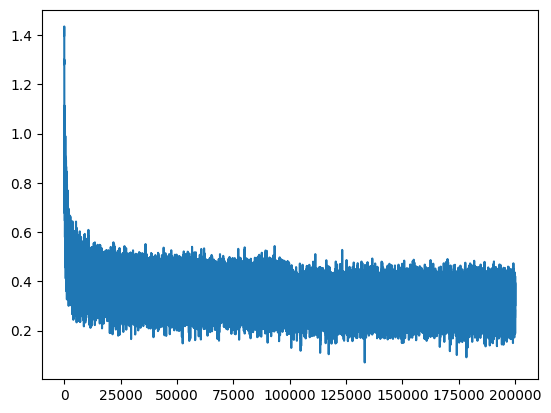

In [19]:
plt.plot(stepi, lossi)

## Evaluation

### Loss on Different Sets
- **Training loss**: Loss on training set (Xtr, Ytr)
- **Development loss**: Loss on dev set (Xde, Yde)
- **Test loss**: Loss on test set (Xte, Yte)

### Interpreting Results
- Training loss should be comparable to dev loss
- Large gap indicates overfitting
- Lower loss = better model performance

### Visualizing Embeddings
- 2D embedding visualization (using PCA or similar)
- Shows how characters cluster in embedding space

In [22]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
logits = h @ W2 + B2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1144, device='cuda:0', grad_fn=<NllLossBackward0>)

In [23]:
emb = C[Xde]
h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
logits = h @ W2 + B2
loss = F.cross_entropy(logits, Yde)
loss

tensor(2.1621, device='cuda:0', grad_fn=<NllLossBackward0>)

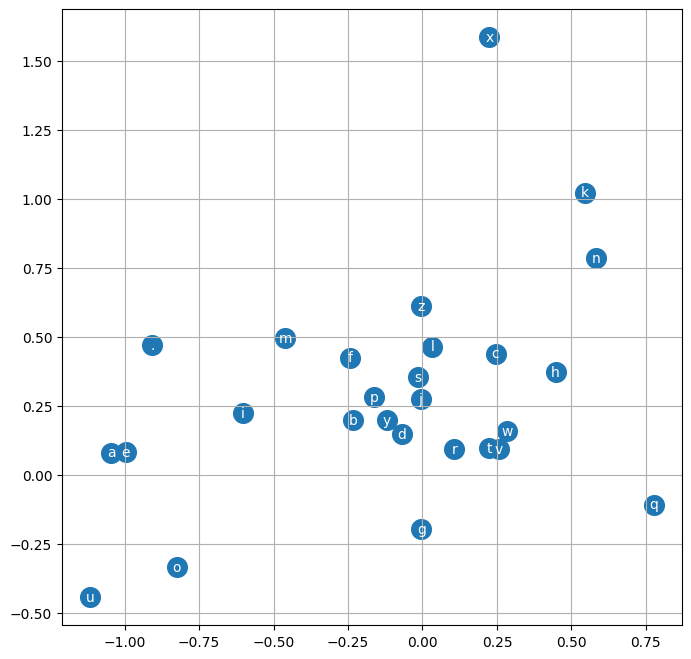

In [26]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].to('cpu').data, C[:,1].to('cpu').data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')



## Sample Generation

In [27]:
block_size = 3
content = [0] * block_size
C[torch.tensor([content])].shape

torch.Size([1, 3, 10])

In [32]:
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0]*block_size
    while True:
        emb = C[torch.tensor([context], device=device)]
        h = torch.tanh(emb.view(-1, 30) @ W1 + B1)
        logits = h @ W2 + B2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix ==0:
            break
    name = ''.join(itos[i] for i in out)[:-1]
    print(f'Generated name: {name}\t In dataset: {name in words}')


Generated name: brentzy	 In dataset: False
Generated name: yuriah	 In dataset: True
Generated name: frylah	 In dataset: False
Generated name: sharbrances	 In dataset: False
Generated name: didiyonurah	 In dataset: False
Generated name: emin	 In dataset: True
Generated name: jacton	 In dataset: False
Generated name: greganton	 In dataset: False
Generated name: dmeth	 In dataset: False
Generated name: brelloni	 In dataset: False
Generated name: arshtenttennah	 In dataset: False
Generated name: chy	 In dataset: False
Generated name: mar	 In dataset: True
Generated name: haann	 In dataset: False
Generated name: jurlana	 In dataset: False
Generated name: dorgh	 In dataset: False
Generated name: driel	 In dataset: False
Generated name: thi	 In dataset: True
Generated name: braydis	 In dataset: False
Generated name: adrithik	 In dataset: False
